In [ ]:
import kagglehub

spaceship_titanic_path = kagglehub.competition_download('spaceship-titanic')

print('Data source import complete.')


100%|██████████| 299k/299k [00:00<00:00, 65.0MB/s]

Extracting files...
Data source import complete.


In [ ]:
print(spaceship_titanic_path)

/root/.cache/kagglehub/competitions/spaceship-titanic


In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/content/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/content/.config/gce
/content/.config/.last_opt_in_prompt.yaml
/content/.config/.last_survey_prompt.yaml
/content/.config/active_config
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/default_configs.db
/content/.config/.last_update_check.json
/content/.config/config_sentinel
/content/.config/logs/2026.06.04/13.32.02.654775.log
/content/.config/logs/2026.06.04/13.31.42.499627.log
/content/.config/logs/2026.06.04/13.32.39.344962.log
/content/.config/logs/2026.06.04/13.32.18.735754.log
/content/.config/logs/2026.06.04/13.32.38.346437.log
/content/.config/logs/2026.06.04/13.32.21.210570.log
/content/.config/configurations/config_default
/content/sample_data/anscombe.json
/content/sample_data/README.md
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_test.csv


Viewing the dataset, to look at the kinds of values in the set

In [ ]:
train_df = pd.read_csv(f"{spaceship_titanic_path}/train.csv")
test_df = pd.read_csv(f"{spaceship_titanic_path}/test.csv")


train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
train_df.shape

(8693, 14)

Checking for null values

In [ ]:
(train_df.isnull().sum() / len(train_df)) * 100

,0
PassengerId,0.000000
HomePlanet,2.312205
CryoSleep,2.496261
Cabin,2.289198
Destination,2.093639
Age,2.059128
VIP,2.335212
RoomService,2.082135
FoodCourt,2.105142
ShoppingMall,2.392730


Checking if any of the categorical columns have spelling errors or non uniform spellings (Earth and earth for instance)

In [ ]:
categorical = train_df.select_dtypes(include="object").columns

for col in categorical:
  print(col, train_df[col].unique(), "\n")

PassengerId ['0001_01' '0002_01' '0003_01' ... '9279_01' '9280_01' '9280_02'] 

HomePlanet ['Europa' 'Earth' 'Mars' nan] 

CryoSleep [False True nan] 

Cabin ['B/0/P' 'F/0/S' 'A/0/S' ... 'G/1499/S' 'G/1500/S' 'E/608/S'] 

Destination ['TRAPPIST-1e' 'PSO J318.5-22' '55 Cancri e' nan] 

VIP [False True nan] 

Name ['Maham Ofracculy' 'Juanna Vines' 'Altark Susent' ... 'Fayey Connon'
 'Celeon Hontichre' 'Propsh Hontichre'] 



Although a lot of the spending columns have null values, they might be related to people who are in cryosleep. If someone is in cryosleep and the spending column is null, that is probably fine and can be replaced by 0's

In [ ]:
spending_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

In [ ]:
train_df.groupby('CryoSleep')[spending_cols].apply(lambda x: x.isnull().sum())

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
CryoSleep,,,,,
False,111,110,104,113,119
True,68,70,96,65,62


In [ ]:
train_df[train_df['CryoSleep'] == True][spending_cols].describe() ##Checking if my assumption of spending 0 is true

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,2969.0,2967.0,2941.0,2972.0,2975.0
mean,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0


I must first deal with all the rows where cryosleep is null, before I can apply the spending_cols to 0 rule

In [ ]:
train_df["CryoSleep"].value_counts()

,count
CryoSleep,
False,5439
True,3037


In [ ]:
known = train_df[train_df['CryoSleep'].notnull()].copy()
known['total_spend'] = known[spending_cols].sum(axis=1)
pd.crosstab(known['CryoSleep'], known['total_spend'] == 0)

total_spend,False,True
CryoSleep,,
False,4921,518
True,0,3037


From the above, we can infer that if cryosleep is true, then spending will always be 0

If cryosleep is false spending can be either true or false

using this I can fill in the cryosleep null values to be True wherever the total_spend is > 0

In [ ]:
spend_sum = train_df[spending_cols].sum(axis=1)
cryo_nulls = train_df["CryoSleep"].isnull()

train_df.loc[cryo_nulls & (spend_sum > 0), "CryoSleep"] = False

In [ ]:
(train_df.isnull().sum() / len(train_df)) * 100

,0
PassengerId,0.000000
HomePlanet,2.312205
CryoSleep,1.127344
Cabin,2.289198
Destination,2.093639
Age,2.059128
VIP,2.335212
RoomService,2.082135
FoodCourt,2.105142
ShoppingMall,2.392730


The cryosleep columns with a missing vaue went down from 2.49% to 1.12%

In [ ]:
train_df["CryoSleep"] = train_df["CryoSleep"].fillna("unkown")

Now I will change all the spending column NaN values to 0's wherever CryoSleep is true

In [ ]:
train_df.loc[train_df["CryoSleep"] == True, spending_cols] = train_df.loc[train_df["CryoSleep"] == True, spending_cols].fillna(0)

In [ ]:
train_df[spending_cols].describe()

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8580.000000,8580.000000,8581.000000,8575.000000,8567.000000
mean,222.906876,454.339977,171.785573,308.780292,302.648535
std,664.368930,1605.430304,601.581625,1132.710170,1141.855811
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,44.000000,70.000000,24.000000,58.000000,44.000000
max,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [ ]:
train_df[spending_cols].median()

,0
RoomService,0.0
FoodCourt,0.0
ShoppingMall,0.0
Spa,0.0
VRDeck,0.0


Turns out the median value of spend is 0, I could've just done fillna(0) directly

In [ ]:
train_df[spending_cols] = train_df[spending_cols].fillna(0)

In [ ]:
train_df.isnull().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,0
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,0
FoodCourt,0
ShoppingMall,0


The data card says that the passengerId is split into group_id and passenger_id, I can split this into two new columns and drop the passengerId column

In [ ]:
train_df[["group_id", "passenger_id"]] = train_df["PassengerId"].astype(str).str.split("_", expand=True)
train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,group_id,passenger_id
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0001,01
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,0002,01
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,0003,01
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,0003,02
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,0004,01


I can safely drop the passengerId column

In [ ]:
train_df = train_df.drop(columns=["PassengerId"])

Similarly I can split the Cabin into deck, number and side

In [ ]:
train_df[["deck", "number", "side"]] = train_df["Cabin"].astype(str).str.split("/", expand=True)

In [ ]:
train_df.head()

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,group_id,passenger_id,deck,number,side
0,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0001,01,B,0,P
1,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,0002,01,F,0,S
2,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,0003,01,A,0,S
3,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,0003,02,A,0,S
4,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,0004,01,F,1,S


I can now safely drop the Cabin column

In [ ]:
train_df = train_df.drop(columns=["Cabin"])

In [ ]:
train_df.isnull().sum()

,0
HomePlanet,201
CryoSleep,0
Destination,182
Age,179
VIP,203
RoomService,0
FoodCourt,0
ShoppingMall,0
Spa,0
VRDeck,0


In [ ]:
train_df[['deck','number','side']].isnull().sum()

,0
deck,0
number,199
side,199


In [ ]:
train_df[train_df['number'].isnull()][['deck','number','side']].head(10)

,deck,number,side
15,nan,None,None
93,nan,None,None
103,nan,None,None
222,nan,None,None
227,nan,None,None
251,nan,None,None
260,nan,None,None
272,nan,None,None
280,nan,None,None
295,nan,None,None


In [ ]:
train_df['deck'] = train_df['deck'].replace('nan', np.nan)

In [ ]:
train_df.isnull().sum()

,0
HomePlanet,201
CryoSleep,0
Destination,182
Age,179
VIP,203
RoomService,0
FoodCourt,0
ShoppingMall,0
Spa,0
VRDeck,0


In [ ]:
group_deck = train_df.dropna(subset=['deck']).groupby('group_id')['deck'].nunique()
group_side = train_df.dropna(subset=['side']).groupby('group_id')['side'].nunique()

print("Fraction of groups with 1 unique deck:", (group_deck == 1).mean())
print("Fraction of groups with 1 unique side:", (group_side == 1).mean())

Fraction of groups with 1 unique deck: 0.9311866623079438
Fraction of groups with 1 unique side: 1.0


In [ ]:
group_sizes = train_df.groupby('group_id')['passenger_id'].count()
multi_groups = group_sizes[group_sizes > 1].index

multi_deck = train_df[train_df['group_id'].isin(multi_groups)].dropna(subset=['deck']).groupby('group_id')['deck'].nunique()
multi_side = train_df[train_df["group_id"].isin(multi_groups)].dropna(subset=["side"]).groupby("group_id")["side"].nunique()
print("Fraction of MULTI-passenger groups sharing 1 deck:", (multi_deck == 1).mean())
print("Fraction of MULTI-passenger groups sharing 1 side:", (multi_side == 1).mean())

Fraction of MULTI-passenger groups sharing 1 deck: 0.7018413597733711
Fraction of MULTI-passenger groups sharing 1 side: 1.0


I can impute that all the passengers in a group will be in the same side, although the passengers in a group are only on the same deck 70% of the time, this is good enough for imputing the values, since only about 2% of the data is NaN

In [ ]:
group_side_map = train_df.dropna(subset=['side']).groupby('group_id')['side'].agg(lambda x: x.mode()[0])

mask = train_df['side'].isnull()
train_df.loc[mask, 'side'] = train_df.loc[mask, 'group_id'].map(group_side_map)

train_df['side'].isnull().sum()

np.int64(99)

In [ ]:
group_deck_map = train_df.dropna(subset=['deck']).groupby('group_id')['deck'].agg(lambda x: x.mode()[0])

mask_group = train_df['deck'].isnull()
train_df.loc[mask_group, 'deck'] = train_df.loc[mask_group, 'group_id'].map(group_deck_map)

train_df['deck'].isnull().sum()

np.int64(99)

All of the remaining passengers are travelling alone, there's nothing I can impute, so I'll fill in their null values using unknown

In [ ]:
train_df["deck"] = train_df["deck"].fillna("unknown")
train_df["side"] = train_df["side"].fillna("unknown")
train_df["number"] = train_df["number"].fillna(-1)

In [ ]:
train_df.isnull().sum()

,0
HomePlanet,201
CryoSleep,0
Destination,182
Age,179
VIP,203
RoomService,0
FoodCourt,0
ShoppingMall,0
Spa,0
VRDeck,0


In [ ]:
train_df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,group_id,passenger_id,deck,number,side
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0001,01,B,0,P
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,0002,01,F,0,S
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,0003,01,A,0,S
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,0003,02,A,0,S
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,0004,01,F,1,S


In [ ]:
train_df['Surname'] = train_df['Name'].str.split(' ').str[-1]

In [ ]:
placeholder = pd.Series('Unknown_' + train_df.index.astype(str), index=train_df.index)
train_df['Surname'] = train_df['Surname'].fillna(placeholder)

In [ ]:
train_df.isnull().sum()

,0
HomePlanet,201
CryoSleep,0
Destination,182
Age,179
VIP,203
RoomService,0
FoodCourt,0
ShoppingMall,0
Spa,0
VRDeck,0


In [ ]:
train_df = train_df.drop(columns=["Name"])

I can most likely guess that all the passengers in one group started at the same source and might end up going to the same destination

In [ ]:
multi_groups = train_df.groupby('group_id')['passenger_id'].transform('count') > 1
multi_hp = train_df[multi_groups].dropna(subset=['HomePlanet']).groupby('group_id')['HomePlanet'].nunique()
print("Fraction of multi-passenger groups sharing 1 HomePlanet:", (multi_hp == 1).mean())

Fraction of multi-passenger groups sharing 1 HomePlanet: 1.0


In [ ]:
multi_dest = train_df[multi_groups].dropna(subset=['Destination']).groupby('group_id')['Destination'].nunique()
print("Fraction of multi-passenger groups sharing 1 Destination:", (multi_dest == 1).mean())

Fraction of multi-passenger groups sharing 1 Destination: 0.4922096317280453


Clearly, the fraction of passengers sharing the same destination is not reliable enough to impute the value, I will impute the value for source and fill in unknown for destination

In [ ]:
group_hp_map = train_df.dropna(subset=['HomePlanet']).groupby('group_id')['HomePlanet'].agg(lambda x: x.mode()[0])
mask = train_df['HomePlanet'].isnull()
train_df.loc[mask, 'HomePlanet'] = train_df.loc[mask, 'group_id'].map(group_hp_map)

In [ ]:
train_df["Destination"] = train_df["Destination"].fillna("unknown")

In [ ]:
train_df["HomePlanet"] = train_df["HomePlanet"].fillna("unknown")

In [ ]:
train_df.isnull().sum()

,0
HomePlanet,0
CryoSleep,0
Destination,0
Age,179
VIP,203
RoomService,0
FoodCourt,0
ShoppingMall,0
Spa,0
VRDeck,0


In [ ]:
train_df["VIP"].value_counts()

,count
VIP,
False,8291
True,199


In [ ]:
train_df["VIP"] = train_df["VIP"].fillna("unknown")
train_df["Age"] = train_df["Age"].fillna(train_df["Age"].median())

In [ ]:
train_df.duplicated().sum()

np.int64(0)

In [ ]:
train_df[['Age'] + spending_cols].describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000
mean,28.790291,220.009318,448.434027,169.572300,304.588865,298.261820
std,14.341404,660.519050,1595.790627,598.007164,1125.562559,1134.126417
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,41.000000,61.000000,22.000000,53.000000,40.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [ ]:
train_df[["Age"] + spending_cols].median()

,0
Age,27.0
RoomService,0.0
FoodCourt,0.0
ShoppingMall,0.0
Spa,0.0
VRDeck,0.0


In [ ]:
train_df.columns

Index(['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService',
       'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'group_id',
       'passenger_id', 'deck', 'number', 'side', 'Surname'],
      dtype='object')

In [ ]:
train_df['CryoSleep'] = train_df['CryoSleep'].replace('unkown', 'unknown')

In [ ]:
train_df['CryoSleep'] = train_df['CryoSleep'].astype(str)
train_df['CryoSleep'].unique()

array(['False', 'True', 'unknown'], dtype=object)

In [ ]:
cols_to_fix = ["CryoSleep", "VIP"] # Ensure these are your exact columns

# 1. Create a dictionary that catches strings, actual booleans, and your "unknown" text
bool_mapping = {
    'True': True,
    'False': False,
    True: True,
    False: False,
    'unknown': pd.NA  # pd.NA is pandas' native missing value for the boolean type
}

# 2. Apply the map and cast to boolean
for col in cols_to_fix:
    train_df[col] = train_df[col].map(bool_mapping).astype("boolean")

train_df[cols_to_fix].head()

,CryoSleep,VIP
0,False,False
1,False,False
2,False,True
3,False,False
4,False,False


In [ ]:
train_df["number"] = train_df["number"].astype(np.float64)

In [ ]:
train_df.to_parquet('train_cleaned.parquet')

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
train_df = pd.read_parquet('train_cleaned.parquet')

train_df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,group_id,passenger_id,deck,number,side,Surname
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,0001,01,B,0.0,P,Ofracculy
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,0002,01,F,0.0,S,Vines
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,0003,01,A,0.0,S,Susent
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,0003,02,A,0.0,S,Susent
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,0004,01,F,1.0,S,Santantines


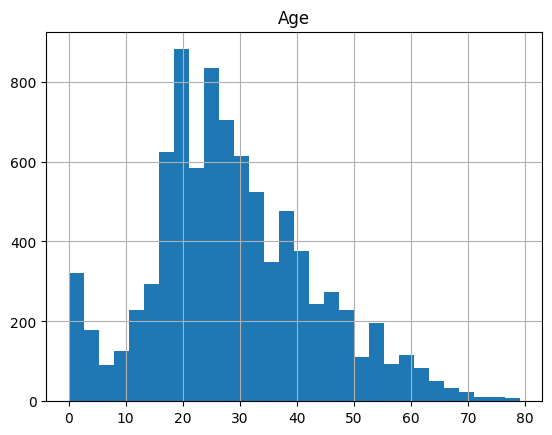

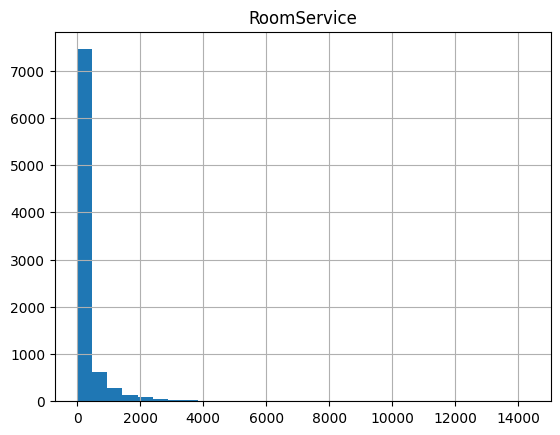

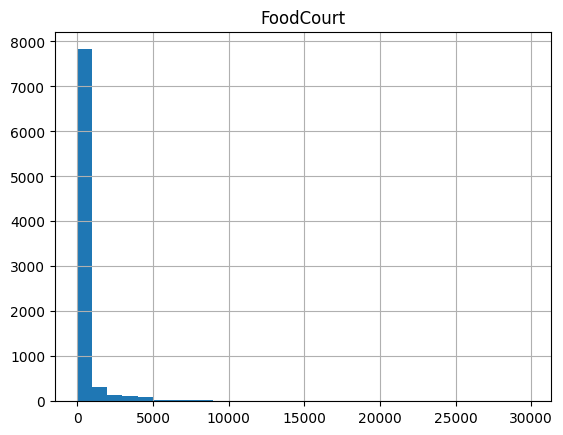

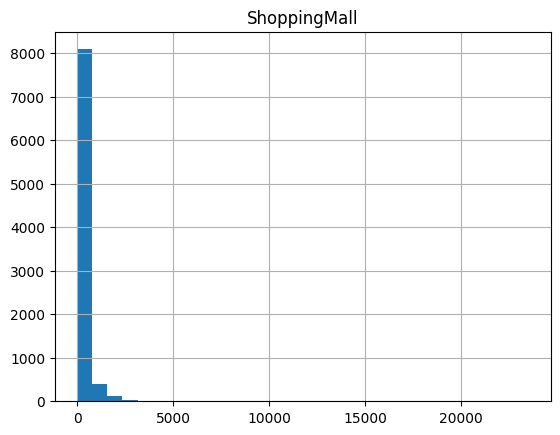

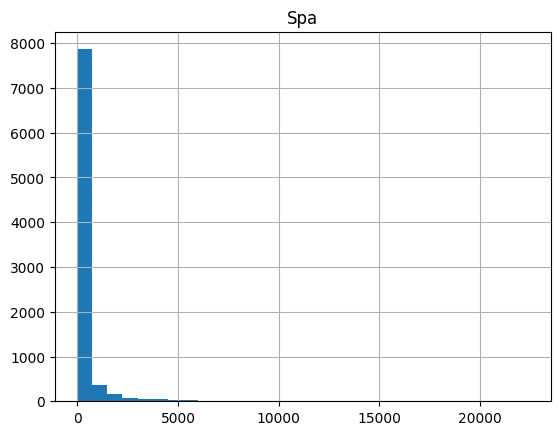

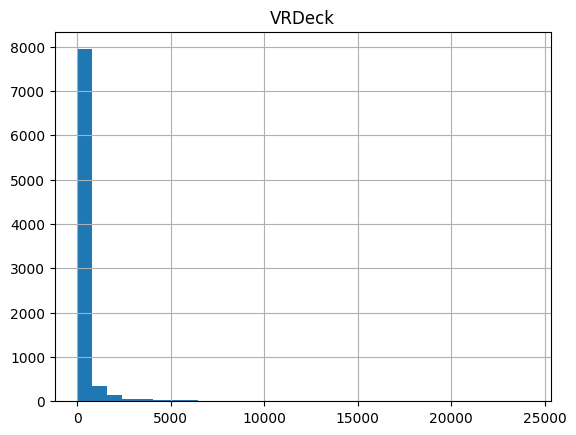

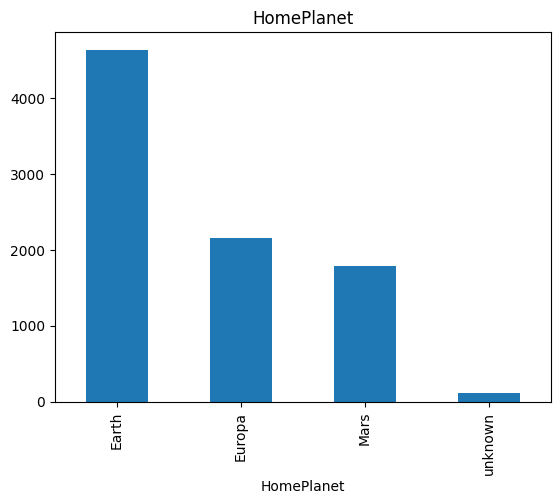

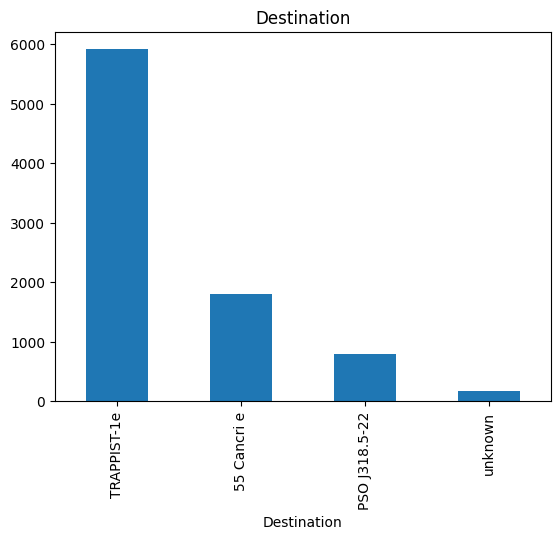

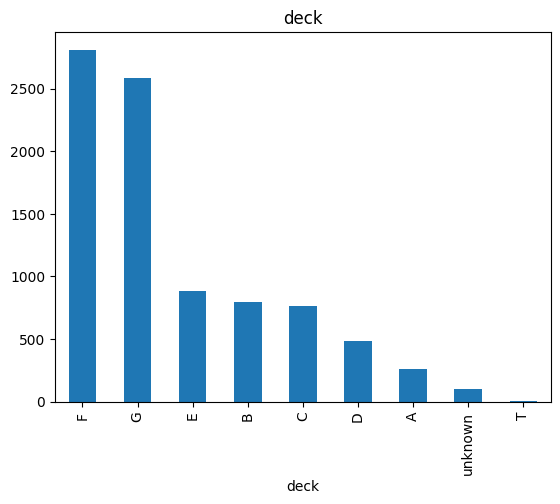

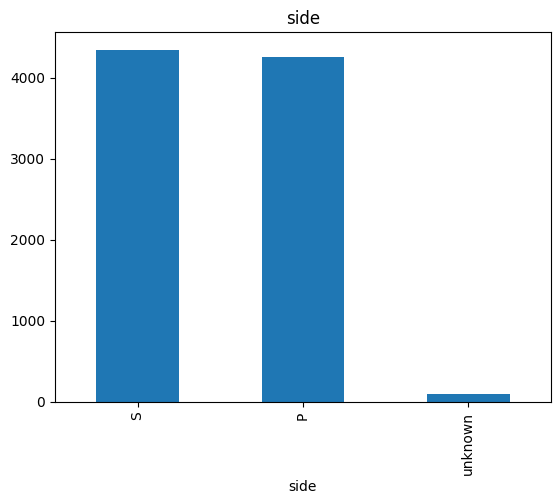

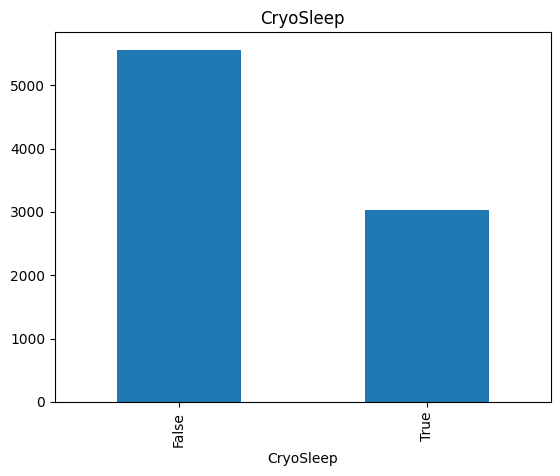

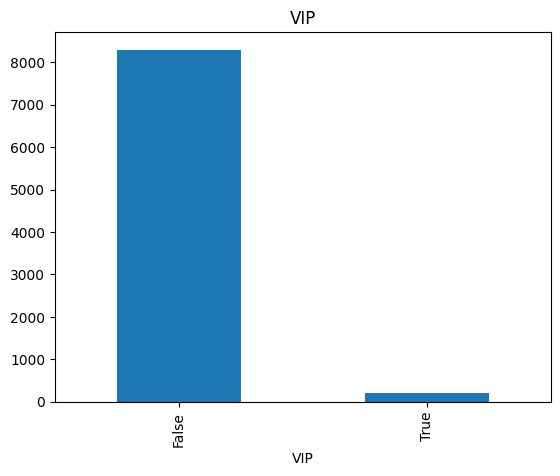

In [7]:
spending_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
numeric_cols = ['Age'] + spending_cols
categorical_cols = ['HomePlanet', 'Destination', 'deck', 'side', 'CryoSleep', 'VIP']

for col in numeric_cols:
    train_df[col].hist(bins=30)
    plt.title(col)
    plt.show()

for col in categorical_cols:
    train_df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

My obeservations:

Age: There's a large amount of children between the ages of 0 and 2.5, which then drops. Most of the passengers are 18-30 years old, after which the number of people gradually decreases till 60. The graph sort of extends from there upto 80 indicating to me that the number of elderly aboard the spaceship was low

Spending columns: Most of the passengers did not spend any money at all, there's a peak at 0 and a small tail that stops before 10000.

HomePlanet: About 5000 people are from Earth, with Europa and Mars have 2200 and 1800 people ish respectively, The number of unknowns is low with it being around 200

Destination: Most of our passengers, around 6000 are going to Trappist-1e, with 2000 and 1000 people going to 55 Cancri e and PSO. Again the number of unknowns looks to be in the 100s

Deck: The vast majority of passengers are on decks F and G. Deck T barely has any people on it, with there being more unknown's than deck D.

Side: The people are divided almost equally amongst starboard and portside

Cryosleep: only around 3000 passengers are in cryosleep, with the vast majority not in it

VIP: only 199 passengers are VIP, with most of the passengers being non VIP as expected

In [8]:
from scipy import stats

group_true = train_df[train_df['Transported'] == True]['Age']
group_false = train_df[train_df['Transported'] == False]['Age']

print(stats.shapiro(group_true))
print(stats.shapiro(group_false))

ShapiroResult(statistic=np.float64(0.9816481633964124), pvalue=np.float64(2.1327496435474573e-23))
ShapiroResult(statistic=np.float64(0.9710332915909673), pvalue=np.float64(1.0821695659279825e-28))


In [10]:
from scipy.stats import chi2_contingency

for col in ['HomePlanet', 'Destination', 'deck', 'side', 'VIP']:
    contingency = pd.crosstab(train_df[col], train_df['Transported'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(col)
    print(expected)
    print('---')

HomePlanet
[[2300.20821351 2333.79178649]
 [1072.66938916 1088.33061084]
 [ 887.02461751  899.97538249]
 [  55.09777982   55.90222018]]
---
Destination
[[ 893.47751064  906.52248936]
 [ 395.11561026  400.88438974]
 [2936.06637524 2978.93362476]
 [  90.34050385   91.65949615]]
---
deck
[[ 130.05061544  131.94938456]
 [ 395.11561026  400.88438974]
 [ 377.74243644  383.25756356]
 [ 241.73530427  245.26469573]
 [ 439.2931094   445.7068906 ]
 [1394.81766939 1415.18233061]
 [1284.62210974 1303.37789026]
 [   2.48188197    2.51811803]
 [  49.14126309   49.85873691]]
---
side
[[2110.0960543  2140.9039457 ]
 [2155.76268262 2187.23731738]
 [  49.14126309   49.85873691]]
---
VIP
[[4117.17974087 4173.82025913]
 [  98.82025913  100.17974087]]
---


In [11]:
pd.crosstab(train_df['deck'], train_df['Transported'])

Transported,False,True
deck,,
A,130,132
B,213,583
C,243,518
D,276,211
E,566,319
F,1575,1235
G,1253,1335
T,4,1
unknown,55,44


In [12]:
train_df["deck"].value_counts()

,count
deck,
F,2810
G,2588
E,885
B,796
C,761
D,487
A,262
unknown,99
T,5


In [21]:
train_df['deck_grouped'] = train_df['deck'].replace({'T': 'unknown'})

In [22]:
contingency = pd.crosstab(train_df['deck_grouped'], train_df['Transported'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(expected)

[[ 130.05061544  131.94938456]
 [ 395.11561026  400.88438974]
 [ 377.74243644  383.25756356]
 [ 241.73530427  245.26469573]
 [ 439.2931094   445.7068906 ]
 [1394.81766939 1415.18233061]
 [1284.62210974 1303.37789026]
 [  51.62314506   52.37685494]]


In [24]:
stat, p_value = stats.mannwhitneyu(group_true, group_false)
print(p_value)

9.574725064029599e-11


In [25]:
group_true.median(), group_false.median()

(27.0, 27.0)

In [26]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(group_true, group_false)
n1, n2 = len(group_true), len(group_false)
rank_biserial = 1 - (2 * stat) / (n1 * n2)
print(rank_biserial)

0.08015263296361719


Age likely has a really low p-value due to the size of the stateset. Although, we can reject the null hypothesis, the relationship is weak

In [28]:
results = []

for col in spending_cols:
    group_true = train_df[train_df['Transported'] == True][col]
    group_false = train_df[train_df['Transported'] == False][col]

    stat, p_value = mannwhitneyu(group_true, group_false)
    n1, n2 = len(group_true), len(group_false)
    rank_biserial = 1 - (2 * stat) / (n1 * n2)

    results.append({
        'column': col,
        'p_value': p_value,
        'rank_biserial': rank_biserial,
        'median_true': group_true.median(),
        'median_false': group_false.median()
    })

results_df = pd.DataFrame(results)
results_df

,column,p_value,rank_biserial,median_true,median_false
0,RoomService,2.695180e-252,0.353919,0.0,1.0
1,FoodCourt,1.230152e-67,0.183517,0.0,0.0
2,ShoppingMall,2.002614e-99,0.219913,0.0,0.0
3,Spa,2.497450e-255,0.365071,0.0,2.0
4,VRDeck,1.304913e-229,0.340147,0.0,1.0


The p-values indicate that these relationships are also not due to chance, but are low because of the size of the dataset. the rank biserial effect measure on the other hand might indicate that these columns have a moderate effect on the target variable

In [29]:
from scipy.stats import chi2_contingency

def cramers_v(contingency):
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    v = np.sqrt(chi2 / (n * min_dim))
    return chi2, p, v

In [30]:
cat_results = []

for col in ['HomePlanet', 'Destination', 'deck_grouped', 'side', 'CryoSleep', 'VIP']:
    contingency = pd.crosstab(train_df[col], train_df['Transported'])
    chi2, p, v = cramers_v(contingency)
    cat_results.append({'column': col, 'chi2': chi2, 'p_value': p, 'cramers_v': v})

cat_results_df = pd.DataFrame(cat_results)
cat_results_df

,column,chi2,p_value,cramers_v
0,HomePlanet,332.155525,1.089574e-71,0.195473
1,Destination,106.394882,6.547434e-23,0.110631
2,deck_grouped,394.173980,4.234403e-81,0.212941
3,side,93.837648,4.201590e-21,0.103897
4,CryoSleep,1879.615020,0.000000e+00,0.467640
5,VIP,11.542021,6.804065e-04,0.036871


In [32]:
surname_groups = train_df.dropna(subset=['Surname']).groupby('Surname')['group_id'].nunique()
multi_group_surnames = surname_groups[surname_groups > 1].index

subset = train_df[train_df['Surname'].isin(multi_group_surnames)]

avg_std = subset.groupby('Surname')['Transported'].std().mean()
overall_std = train_df['Transported'].std()
print("Avg within-surname std:", avg_std)
print("Overall baseline std:", overall_std)

Avg within-surname std: 0.42561576018260744
Overall baseline std: 0.5000156298104965


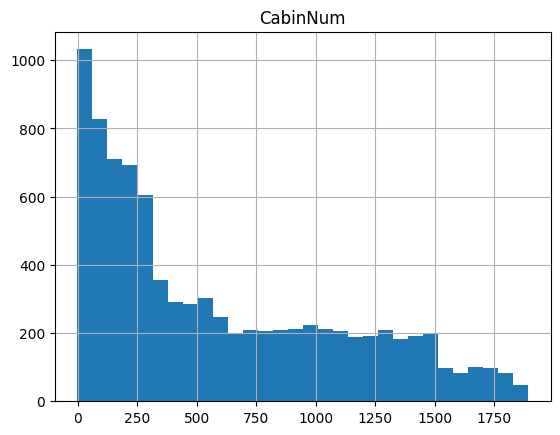

In [33]:
train_df['number'].hist(bins=30)
plt.title('CabinNum')
plt.show()

In [35]:
group_true = train_df[train_df['Transported'] == True]['number']
group_false = train_df[train_df['Transported'] == False]['number']

stat, p_value = mannwhitneyu(group_true, group_false)
n1, n2 = len(group_true), len(group_false)
rank_biserial = 1 - (2 * stat) / (n1 * n2)

p_value, rank_biserial

(np.float64(4.182991272741429e-05), np.float64(0.05074561684436085))

All features tested show statistically significant relationships with Transported (p < 0.05), largely driven by the dataset's sample size (~8700 rows). Effect size (Cramér's V for categorical, rank-biserial correlation for numeric) was used as the primary signal for feature usefulness rather than p-value alone. CryoSleep shows by far the strongest relationship, followed by the spending columns and deck/HomePlanet at moderate strength. Age, CabinNum, and VIP show the weakest individual effects

In [38]:
train_df.columns

Index(['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService',
       'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'group_id',
       'passenger_id', 'deck', 'number', 'side', 'Surname', 'deck_grouped'],
      dtype='object')

In [40]:
train_df = train_df.drop(columns=["passenger_id"])

In [41]:
train_df.columns

Index(['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService',
       'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'group_id',
       'deck', 'number', 'side', 'Surname', 'deck_grouped'],
      dtype='object')

In [42]:
train_df = train_df.drop(columns=["deck"])

In [43]:
train_df.columns

Index(['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService',
       'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'group_id',
       'number', 'side', 'Surname', 'deck_grouped'],
      dtype='object')

In [44]:
train_df = train_df.drop(columns=['Surname', "group_id"])

In [46]:
train_df = train_df.drop(columns=["number"])

In [47]:
train_df.columns

Index(['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService',
       'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'side',
       'deck_grouped'],
      dtype='object')

In [48]:
train_df = train_df.drop(columns="VIP")

In [49]:
train_df.columns

Index(['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'RoomService',
       'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'side',
       'deck_grouped'],
      dtype='object')

In [50]:
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'side', 'deck_grouped']
for col in cat_cols:
    train_df[col] = train_df[col].astype('category')

In [51]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

le = LabelEncoder()
train_df['Transported'] = le.fit_transform(train_df['Transported'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'side', 'deck_grouped']

ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
encoded = ohe.fit_transform(train_df[cat_cols])


encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cat_cols),
    index=train_df.index
)

train_df = train_df.drop(columns=cat_cols)
train_df = pd.concat([train_df, encoded_df], axis=1)

train_df.head()

{np.False_: np.int64(0), np.True_: np.int64(1)}


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_unknown,...,Destination_unknown,side_S,side_unknown,deck_grouped_B,deck_grouped_C,deck_grouped_D,deck_grouped_E,deck_grouped_F,deck_grouped_G,deck_grouped_unknown
0,39.0,0.0,0.0,0.0,0.0,0.0,0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,24.0,109.0,9.0,25.0,549.0,44.0,1,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,58.0,43.0,3576.0,0.0,6715.0,49.0,0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,33.0,0.0,1283.0,371.0,3329.0,193.0,0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,16.0,303.0,70.0,151.0,565.0,2.0,1,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [52]:
train_df.columns

Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Transported', 'HomePlanet_Europa', 'HomePlanet_Mars',
       'HomePlanet_unknown', 'CryoSleep_1.0', 'CryoSleep_nan',
       'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e',
       'Destination_unknown', 'side_S', 'side_unknown', 'deck_grouped_B',
       'deck_grouped_C', 'deck_grouped_D', 'deck_grouped_E', 'deck_grouped_F',
       'deck_grouped_G', 'deck_grouped_unknown'],
      dtype='object')

In [53]:
import pickle

with open('onehot_encoder.pkl', 'wb') as f:
    pickle.dump(ohe, f)


with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

In [54]:
from sklearn.model_selection import train_test_split


X = train_df.drop(columns=['Transported'])
y = train_df['Transported']


X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_val.shape)

(6954, 23) (1739, 23)


Building a baseline model

In [55]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(random_state=42, eval_metric='logloss')
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [57]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model_xgb.predict(X_val)
print(accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

0.7981598619896493
              precision    recall  f1-score   support

           0       0.79      0.80      0.80       863
           1       0.80      0.80      0.80       876

    accuracy                           0.80      1739
   macro avg       0.80      0.80      0.80      1739
weighted avg       0.80      0.80      0.80      1739



In [58]:
importances = pd.Series(model_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances)

CryoSleep_1.0                0.549972
deck_grouped_G               0.092583
HomePlanet_Europa            0.047189
deck_grouped_E               0.035397
Spa                          0.024815
CryoSleep_nan                0.023828
VRDeck                       0.023198
side_unknown                 0.020664
HomePlanet_Mars              0.020140
RoomService                  0.019605
FoodCourt                    0.018946
ShoppingMall                 0.015402
side_S                       0.015201
deck_grouped_F               0.015172
deck_grouped_C               0.013839
deck_grouped_B               0.011709
Age                          0.010482
Destination_TRAPPIST-1e      0.009643
HomePlanet_unknown           0.009642
deck_grouped_D               0.007982
Destination_PSO J318.5-22    0.007573
Destination_unknown          0.004225
deck_grouped_unknown         0.002793
dtype: float32


In [65]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800, 900],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3, 0.5]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,          # number of random combinations to try
    scoring='accuracy',
    cv=5,                # 5-fold cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1            # use all available cores
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.9, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}
Best CV score: 0.8054370076907562


In [63]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_val)
print(accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

0.8159861989649224
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       863
           1       0.81      0.83      0.82       876

    accuracy                           0.82      1739
   macro avg       0.82      0.82      0.82      1739
weighted avg       0.82      0.82      0.82      1739



In [64]:
print(random_search.best_params_)

{'subsample': 0.7, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.7}


In [66]:
import pickle

with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

In [67]:
train_df.to_parquet('train_cleaned_final.parquet')